# Forecasting Australia's Unemployment Rate Using Machine Learning: An Interactive Labour Market Decision-Support Dashboard

## 1. Introduction

This project uses **ABS Table 010: Labour force status by Sex, State and Territory** to analyse and forecast unemployment rates across Australian states.

The modelling dataset uses the **seasonally adjusted, Persons** series for the six Australian states:

- New South Wales
- Victoria
- Queensland
- South Australia
- Western Australia
- Tasmania

Australia is retained as a national benchmark for exploratory analysis and dashboard comparisons.

Northern Territory and Australian Capital Territory are not included in the seasonally adjusted modelling dataset because Table 010 does not provide seasonally adjusted series for those territories.

The initial AI task is to forecast each state's unemployment rate **3 months ahead** using historical labour-market indicators and state-specific time-series features.


## 2. Data Preparation

### 2.1 Importing files

In [1]:
# from google.colab import files
# uploaded = files.upload()

### 2.2 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
# FILE_006 = "/content/Table 006. Labour force status by Sex, Western Australia - Trend, Seasonally adjusted and Original.xlsx"
# FILE_X28 = "/content/Table X28. Underutilised persons by State and Territory and Sex - Trend, Seasonally adjusted and Original.xlsx"
FILE_010 = "Dataset\\Table 010. Labour force status by Sex, State.xlsx"
# FILE_017 = "/content/Table 017. Hours worked in all jobs by Employed full-time, part-time and Sex and by State and Territory - Trend a.xlsx"

## Read the file

In [4]:
# FILE_006 = "/content/Table 006.csv"
# df_labour = pd.read_csv(FILE_006, skiprows=range(1, 10))

In [5]:
# df_labour.head(10)

In [6]:
# df_006 = pd.read_excel(FILE_006,
#     sheet_name="Data1",
#     skiprows=10,
#     header=None,
#     usecols="A,C,X,AG,AV,BK,BT",
#     names=[
#         "Date",
#         "Employed_People_000",
#         "Employment_to_Population_Ratio",
#         "Unemployed_People_000",
#         "Unemployment_Rate",
#         "Labour_Force_000",
#          "Participation_Rate"
#     ]
# )

# df_006.head()

In [7]:
REGIONS = [
    "Australia",
    "New South Wales",
    "Victoria",
    "Queensland",
    "South Australia",
    "Western Australia",
    "Tasmania"
]

MODEL_STATES = [
    "New South Wales",
    "Victoria",
    "Queensland",
    "South Australia",
    "Western Australia",
    "Tasmania"
]

In [8]:
def parse_series_description(value):
    """Split an ABS series description into clean components."""
    parts = [
        re.sub(r"\s+", " ", part.replace(">", "")).strip()
        for part in str(value).split(";")
    ]
    return [part for part in parts if part and part.lower() != "nan"]


def find_series_column(raw, variable, region, series_type="Seasonally Adjusted"):
    """Find the column number for one ABS series."""
    metadata = raw.iloc[:10]

    for col in range(1, raw.shape[1]):
        parts = parse_series_description(metadata.iloc[0, col])
        current_type = str(metadata.iloc[2, col]).strip()

        if (
            len(parts) >= 3
            and variable in parts[0]
            and parts[1] == "Persons"
            and parts[2] == region
            and current_type == series_type
        ):
            return col

    raise KeyError(
        f"Could not find: {variable}, {region}, {series_type}"
    )


def extract_variable(sheet, variable, output_name, regions=REGIONS):
    """Extract one seasonally adjusted Persons series for all requested regions."""
    raw = raw_sheets[sheet]

    dates = pd.to_datetime(
        raw.iloc[10:, 0],
        errors="coerce"
    ).dt.to_period("M").dt.to_timestamp()

    frames = []

    for region in regions:
        col = find_series_column(
            raw,
            variable,
            region,
            series_type="Seasonally Adjusted"
        )

        values = pd.to_numeric(
            raw.iloc[10:, col],
            errors="coerce"
        )

        frames.append(
            pd.DataFrame({
                "Date": dates.values,
                "State": region,
                output_name: values.values
            })
        )

    return pd.concat(frames, ignore_index=True)

In [9]:
raw_sheets = {}

for sheet in ["Data1", "Data2", "Data3"]:
    raw_sheets[sheet] = pd.read_excel(
        FILE_010,
        sheet_name=sheet,
        header=None
    )

for sheet, data in raw_sheets.items():
    print(f"{sheet}: {data.shape}")

Data1: (592, 251)
Data2: (592, 251)
Data3: (592, 245)


In [17]:
import os
import pandas as pd

# 1. Find the correct Excel file in /Dataset
excel_files = [f for f in os.listdir('Dataset') if f.endswith('.xlsx')]
print("Found Excel files:", excel_files)

# 2. Use the first matching file OR manually pick the correct one
FILE_010 = "/Dataset/" + excel_files[0]   # or replace with correct filename

# 3. Load sheets safely
raw_sheets = {}

for sheet in ["Data1", "Data2", "Data3"]:
    try:
        raw_sheets[sheet] = pd.read_excel(
            FILE_010,
            sheet_name=sheet,
            header=None
        )
        print(f"Loaded {sheet}")
    except Exception as e:
        print(f"Error loading {sheet}: {e}")

# 4. Print shapes only for successfully loaded sheets
for sheet, data in raw_sheets.items():
    print(f"{sheet}: {data.shape}")


Found Excel files: ['Table 010. Labour force status by Sex, State.xlsx']
Error loading Data1: [Errno 2] No such file or directory: '/Dataset/Table 010. Labour force status by Sex, State.xlsx'
Error loading Data2: [Errno 2] No such file or directory: '/Dataset/Table 010. Labour force status by Sex, State.xlsx'
Error loading Data3: [Errno 2] No such file or directory: '/Dataset/Table 010. Labour force status by Sex, State.xlsx'


## Read the file(PL)

In [ ]:
df_employed = extract_variable(
    "Data1",
    "Employed",
    "Employed_People_000"
)

df_emp_ratio = extract_variable(
    "Data1",
    "Employment to population ratio",
    "Employment_to_Population_Ratio"
)

df_unemployed = extract_variable(
    "Data2",
    "Unemployed total",
    "Unemployed_People_000"
)

df_unemployment = extract_variable(
    "Data2",
    "Unemployment rate",
    "Unemployment_Rate"
)

df_labour_force = extract_variable(
    "Data3",
    "Labour force total",
    "Labour_Force_000"
)

df_participation = extract_variable(
    "Data3",
    "Participation rate",
    "Participation_Rate"
)

In [ ]:
print('--- Extended Debugging for "Employed total" columns ---')
raw = raw_sheets['Data1']
metadata = raw.iloc[:10]

relevant_columns_info = []

for col_idx in range(1, raw.shape[1]): # Iterate through all data columns
    full_description_row0 = str(metadata.iloc[0, col_idx])
    series_type_row2 = str(metadata.iloc[2, col_idx]).strip()

    parsed_parts = parse_series_description(full_description_row0)

    # Check if 'Employed total' is in the full description (row 0)
    if 'Employed total' in full_description_row0:
        info = {
            'column_index': col_idx,
            'full_description_row0': full_description_row0,
            'parsed_parts': parsed_parts,
            'series_type_row2': series_type_row2,
            'region_in_parts': 'Australia' in parsed_parts,
            'employed_total_in_parts0': 'Employed total' in parsed_parts[0] if parsed_parts else False,
            'persons_in_parts1': parsed_parts[1] == 'Persons' if len(parsed_parts) > 1 else False,
            'australia_in_parts2': parsed_parts[2] == 'Australia' if len(parsed_parts) > 2 else False,
        }
        relevant_columns_info.append(info)

if relevant_columns_info:
    for info in relevant_columns_info:
        print(f"\n--- Column {info['column_index']} ---")
        print(f"  Full Description (row 0): {info['full_description_row0']}")
        print(f"  Parsed Parts: {info['parsed_parts']}")
        print(f"  Series Type (from row 2): {info['series_type_row2']}")
        print(f"  'Australia' found in parsed_parts: {info['region_in_parts']}")
        print(f"  'Employed total' in parsed_parts[0]: {info['employed_total_in_parts0']}")
        print(f"  'Persons' == parsed_parts[1]: {info['persons_in_parts1']}")
        print(f"  'Australia' == parsed_parts[2]: {info['australia_in_parts2']}")
else:
    print("No columns found containing 'Employed total' in their description (row 0).")
print('--- End Extended Debugging ---')

--- Extended Debugging for "Employed total" columns ---

--- Column 1 ---
  Full Description (row 0): Employed total ;  Persons ;  Australia ;
  Parsed Parts: ['Employed total', 'Persons', 'Australia']
  Series Type (from row 2): Trend
  'Australia' found in parsed_parts: True
  'Employed total' in parsed_parts[0]: True
  'Persons' == parsed_parts[1]: True
  'Australia' == parsed_parts[2]: True

--- Column 2 ---
  Full Description (row 0): Employed total ;  Persons ;  Australia ;
  Parsed Parts: ['Employed total', 'Persons', 'Australia']
  Series Type (from row 2): Seasonally Adjusted
  'Australia' found in parsed_parts: True
  'Employed total' in parsed_parts[0]: True
  'Persons' == parsed_parts[1]: True
  'Australia' == parsed_parts[2]: True

--- Column 3 ---
  Full Description (row 0): Employed total ;  Persons ;  Australia ;
  Parsed Parts: ['Employed total', 'Persons', 'Australia']
  Series Type (from row 2): Original
  'Australia' found in parsed_parts: True
  'Employed total' in

In [ ]:
dfs = [
    df_employed,
    df_emp_ratio,
    df_unemployed,
    df_unemployment,
    df_labour_force,
    df_participation
]

df_010 = dfs[0].copy()

for current_df in dfs[1:]:
    df_010 = df_010.merge(
        current_df,
        on=["Date", "State"],
        how="outer"
    )

df_010 = (
    df_010
    .sort_values(["State", "Date"])
    .reset_index(drop=True)
)

df_010.head()

,Date,State,Employed_People_000,Employment_to_Population_Ratio,Unemployed_People_000,Unemployment_Rate,Labour_Force_000,Participation_Rate
0,1978-02-01,Australia,5997.419207,57.176380,426.876934,6.644727,6424.296140,61.246011
1,1978-03-01,Australia,6002.872737,57.123207,403.812148,6.302981,6406.684885,60.965875
2,1978-04-01,Australia,6030.672349,57.333052,403.243600,6.267468,6433.915949,61.166652
3,1978-05-01,Australia,6033.080060,57.290559,399.419324,6.209395,6432.499384,61.083473
4,1978-06-01,Australia,6033.812264,57.228476,405.970724,6.304106,6439.782988,61.078958


In [ ]:
df_010.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4074 entries, 0 to 4073
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Date                            4074 non-null   datetime64[ns]
 1   State                           4074 non-null   object        
 2   Employed_People_000             4074 non-null   float64       
 3   Employment_to_Population_Ratio  4074 non-null   float64       
 4   Unemployed_People_000           4074 non-null   float64       
 5   Unemployment_Rate               4074 non-null   float64       
 6   Labour_Force_000                4074 non-null   float64       
 7   Participation_Rate              4074 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 254.8+ KB


In [ ]:
df_010.isna().sum()

,0
Date,0
State,0
Employed_People_000,0
Employment_to_Population_Ratio,0
Unemployed_People_000,0
Unemployment_Rate,0
Labour_Force_000,0
Participation_Rate,0


In [ ]:
print("Shape:", df_010.shape)
print("Date range:", df_010["Date"].min(), "to", df_010["Date"].max())
print("\nRegions:")
print(df_010["State"].value_counts())
print("\nMissing values:")
print(df_010.isna().sum())
print("\nDuplicate State-Date rows:")
print(df_010.duplicated(subset=["State", "Date"]).sum())

Shape: (4074, 8)
Date range: 1978-02-01 00:00:00 to 2026-07-01 00:00:00

Regions:
State
Australia            582
New South Wales      582
Queensland           582
South Australia      582
Tasmania             582
Victoria             582
Western Australia    582
Name: count, dtype: int64

Missing values:
Date                              0
State                             0
Employed_People_000               0
Employment_to_Population_Ratio    0
Unemployed_People_000             0
Unemployment_Rate                 0
Labour_Force_000                  0
Participation_Rate                0
dtype: int64

Duplicate State-Date rows:
0


___

# 3. Exploratory Data Analysis

In [ ]:
df_010.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,4074,2002-04-16 16:54:25.979381504,1978-02-01 00:00:00,1990-03-01 00:00:00,2002-04-16 00:00:00,2014-06-01 00:00:00,2026-07-01 00:00:00,NaN
Employed_People_000,4074.0,2709.846256,162.932601,714.253642,1658.91768,3024.95777,14823.069652,3153.474872
Employment_to_Population_Ratio,4074.0,59.022013,50.642235,56.582092,58.823941,61.500086,67.924767,3.329516
Unemployed_People_000,4074.0,179.7026,8.236027,52.669918,117.647833,193.921803,997.213238,203.623908
Unemployment_Rate,4074.0,6.742166,2.322758,5.246657,6.266653,8.20244,13.261429,2.061211
Labour_Force_000,4074.0,2889.548855,175.832479,761.286184,1776.772739,3185.747686,15510.421404,3341.769503
Participation_Rate,4074.0,63.258266,56.910138,61.176673,63.087803,65.207956,69.886035,2.618213


## 3.1 Summary statistics by state

In [ ]:
state_summary = (
    df_010[df_010["State"].isin(MODEL_STATES)]
    .groupby("State")["Unemployment_Rate"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(3)
)

state_summary

,count,mean,std,min,median,max
State,,,,,,
New South Wales,582,6.315,1.878,2.949,5.770,11.235
Queensland,582,6.914,2.029,3.268,6.502,11.080
South Australia,582,7.219,2.048,3.353,7.039,12.109
Tasmania,582,7.631,2.310,3.282,7.150,13.261
Victoria,582,6.382,1.918,3.246,5.855,12.531
Western Australia,582,6.235,1.970,2.323,6.150,11.438


The state-level summary statistics show meaningful differences in historical unemployment across Australia. **Western Australia recorded the lowest average unemployment rate (6.235%)**, followed closely by New South Wales (6.315%), while **Tasmania recorded the highest average (7.631%)**. Tasmania also had the greatest variability (SD = 2.310) and the highest historical maximum unemployment rate (13.261%).

These differences provide useful cross-sectional variation for modelling because the model will learn from several state labour markets rather than from a single time series.


## 3.1.1 Unemployment rate by state over time

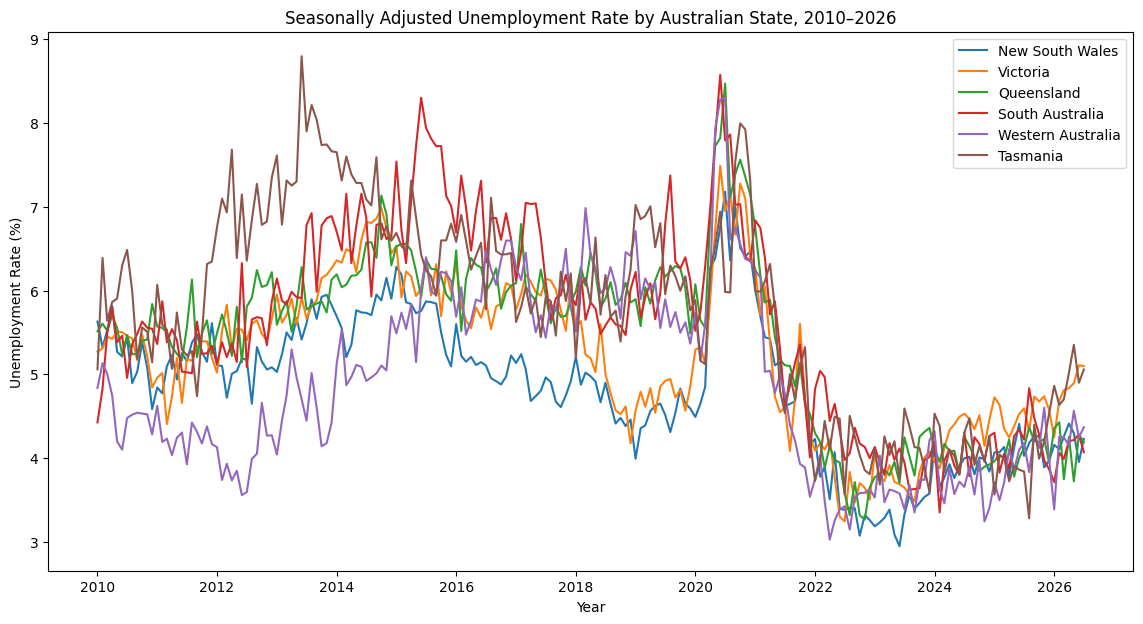

In [ ]:
recent = df_010[df_010["Date"] >= "2010-01-01"]

plt.figure(figsize=(14, 7))

for state in MODEL_STATES:
    state_df = recent[recent["State"] == state]
    plt.plot(
        state_df["Date"],
        state_df["Unemployment_Rate"],
        label=state
    )

plt.title("Seasonally Adjusted Unemployment Rate by Australian State, 2010–2026")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.show()


The unemployment-rate time series shows that the six states share broad national economic cycles while also displaying state-specific differences. Tasmania experienced comparatively high unemployment during parts of the early and mid-2010s, while Western Australia experienced relatively low unemployment during some of the same period before increasing later in the decade.

A major common feature is the sharp rise in unemployment around **2020**, followed by a rapid decline during 2021–2022. Since 2022, unemployment rates have generally remained lower than during much of the 2010s, although several states show a gradual increase toward 2026.

This temporal structure supports the use of lagged unemployment and recent labour-market conditions as forecasting features, while the 2020 disruption highlights the difficulty of predicting major economic shocks.


### 3.1.2 Latest unemplyment rate by state

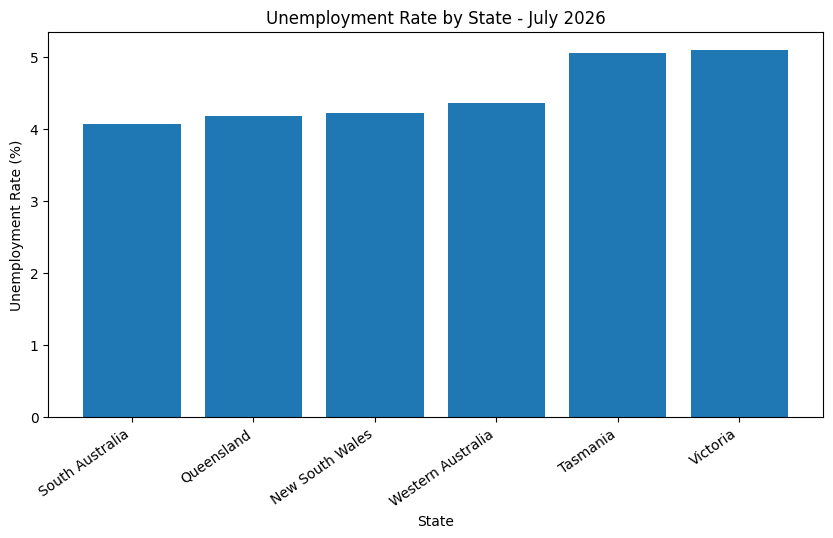

,State,Unemployment_Rate
2327,South Australia,4.071154
1745,Queensland,4.188635
1163,New South Wales,4.229871
4073,Western Australia,4.369273
2909,Tasmania,5.058764
3491,Victoria,5.100287


In [ ]:
latest_date = df_010["Date"].max()

latest_states = (
    df_010[
        (df_010["Date"] == latest_date)
        & (df_010["State"].isin(MODEL_STATES))
    ]
    .sort_values("Unemployment_Rate")
)

plt.figure(figsize=(10, 5))
plt.bar(
    latest_states["State"],
    latest_states["Unemployment_Rate"]
)

plt.title(f"Unemployment Rate by State - {latest_date:%B %Y}")
plt.xlabel("State")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=35, ha="right")
plt.show()

latest_states[
    ["State", "Unemployment_Rate"]
]


The July 2026 comparison shows noticeable differences in current unemployment across the six states. **South Australia had the lowest unemployment rate at approximately 4.07%**, followed by Queensland (4.19%) and New South Wales (4.23%). Western Australia was approximately 4.37%, while Tasmania (5.06%) and Victoria (5.10%) recorded the highest rates among the six states.

This chart is particularly suitable for the proposed dashboard because it allows users to quickly compare the latest labour-market position of each state.


### 3.1.2 Participation rate by state

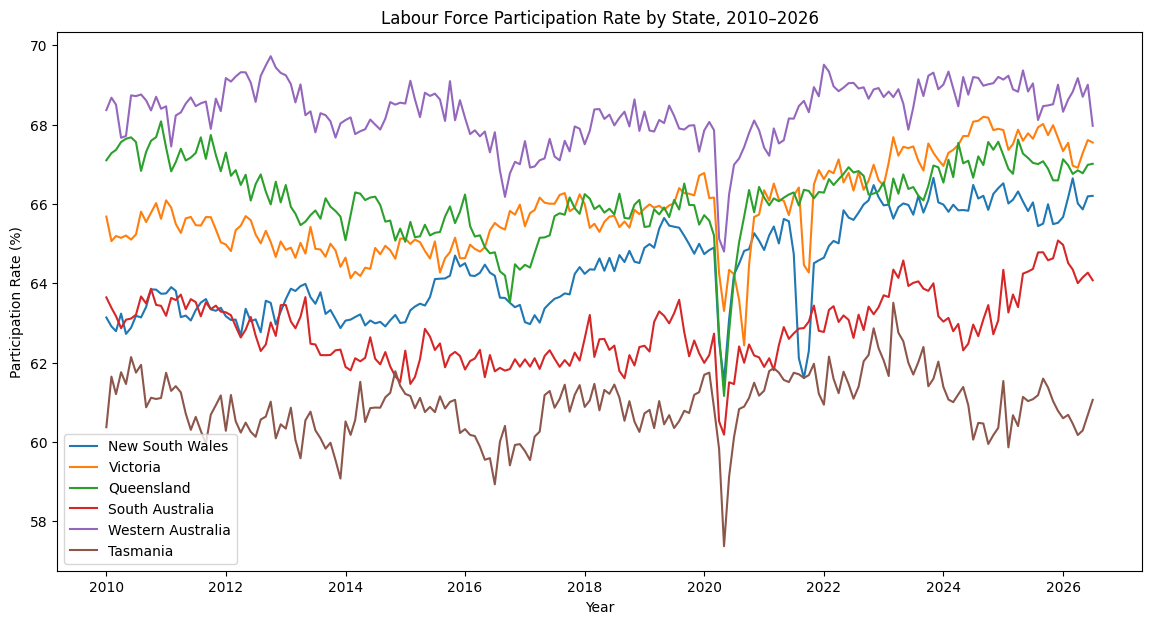

In [ ]:
plt.figure(figsize=(14, 7))

for state in MODEL_STATES:
    state_df = recent[recent["State"] == state]
    plt.plot(
        state_df["Date"],
        state_df["Participation_Rate"],
        label=state
    )

plt.title("Labour Force Participation Rate by State, 2010–2026")
plt.xlabel("Year")
plt.ylabel("Participation Rate (%)")
plt.legend()
plt.show()


Participation rates vary substantially between states as well as over time. Western Australia generally records one of the highest participation rates, while Tasmania remains noticeably lower than the other states. Most states experienced a sharp fall in participation around 2020 followed by recovery.

The participation rate provides important context for unemployment because a lower unemployment rate does not necessarily indicate stronger labour-market conditions if participation is also falling. For this reason, participation is retained as an explanatory labour-market indicator rather than relying on unemployment alone.


### 3.1.3 Employment-to-population ratio by state

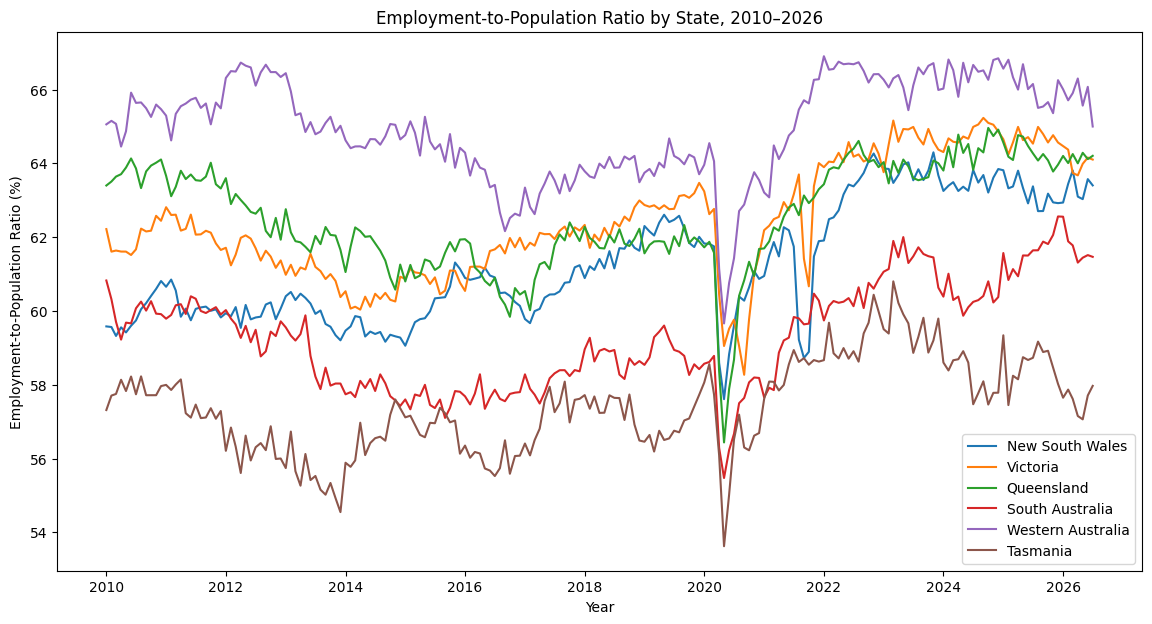

In [ ]:
plt.figure(figsize=(14, 7))

for state in MODEL_STATES:
    state_df = recent[recent["State"] == state]
    plt.plot(
        state_df["Date"],
        state_df["Employment_to_Population_Ratio"],
        label=state
    )

plt.title("Employment-to-Population Ratio by State, 2010–2026")
plt.xlabel("Year")
plt.ylabel("Employment-to-Population Ratio (%)")
plt.legend()
plt.show()

The employment-to-population ratio shows clear differences in labour-market strength across states. Western Australia remains comparatively high through much of the period, whereas Tasmania generally records the lowest ratio. All states show a pronounced decline around 2020 followed by a strong recovery.

Because this measure represents the proportion of the population that is employed, it complements both unemployment and participation. Its movement during major labour-market disruptions suggests that it may provide useful predictive information for unemployment forecasting.

### 3.1.4 Distribution of unemployment by state

/tmp/ipykernel_1065/819000222.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


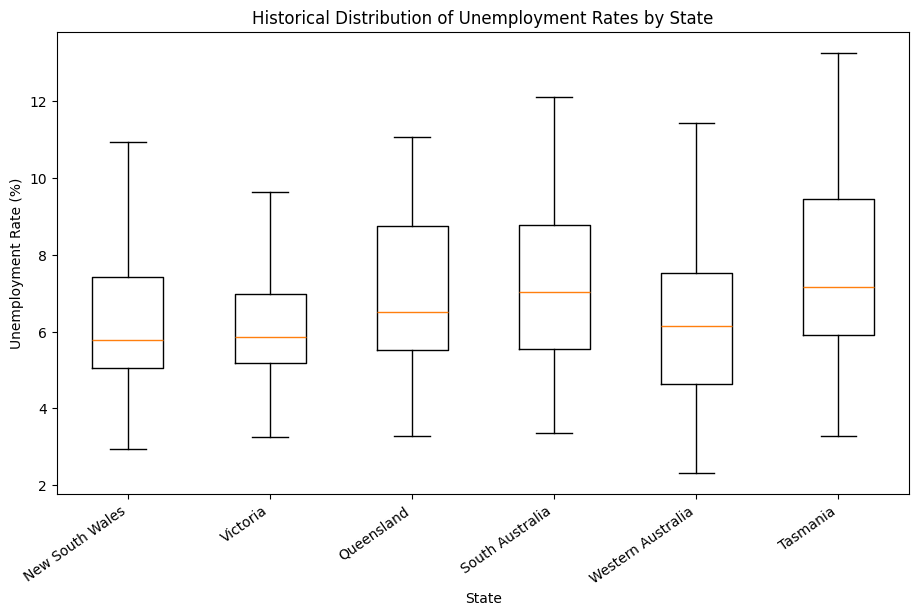

In [ ]:
plot_data = [
    df_010.loc[df_010["State"] == state, "Unemployment_Rate"].dropna()
    for state in MODEL_STATES
]

plt.figure(figsize=(11, 6))
plt.boxplot(
    plot_data,
    labels=MODEL_STATES,
    showfliers=False
)

plt.title("Historical Distribution of Unemployment Rates by State")
plt.xlabel("State")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=35, ha="right")
plt.show()


The boxplot confirms that unemployment has not been distributed equally across states. **Tasmania has the highest historical median unemployment rate (7.150%)**, followed by South Australia (7.039%), and also displays relatively wide variation. New South Wales and Victoria have lower historical medians, while Western Australia has experienced both relatively low unemployment and periods of substantially higher unemployment.

These differences strengthen the case for a multi-state model because the dataset contains a wider range of labour-market conditions than a Western Australia-only dataset.

## 3.2 Summary Statistics

In [ ]:
df_010[
    [
        "Unemployment_Rate",
        "Participation_Rate",
        "Employment_to_Population_Ratio",
        "Employed_People_000",
        "Unemployed_People_000",
        "Labour_Force_000"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Unemployment_Rate,4074.0,6.742166,2.061211,2.322758,5.246657,6.266653,8.202440,13.261429
Participation_Rate,4074.0,63.258266,2.618213,56.910138,61.176673,63.087803,65.207956,69.886035
Employment_to_Population_Ratio,4074.0,59.022013,3.329516,50.642235,56.582092,58.823941,61.500086,67.924767
Employed_People_000,4074.0,2709.846256,3153.474872,162.932601,714.253642,1658.917680,3024.957770,14823.069652
Unemployed_People_000,4074.0,179.702600,203.623908,8.236027,52.669918,117.647833,193.921803,997.213238
Labour_Force_000,4074.0,2889.548855,3341.769503,175.832479,761.286184,1776.772739,3185.747686,15510.421404


Across the complete dataset of 4,074 region-month observations, the unemployment rate averaged approximately **6.74%**, with values ranging from **2.32% to 13.26%**. The participation rate averaged **63.26%**, ranging from approximately **56.91% to 69.89%**, while the employment-to-population ratio averaged **59.02%**.

The raw employment, unemployment and labour-force counts have very large ranges because the table combines states of different population sizes with the Australia-wide aggregate. These count variables should therefore not be compared using their overall means alone. Rates, within-state changes and growth measures are more appropriate for comparing labour-market conditions across states.

In [ ]:
df_010.head(10)

,Date,State,Employed_People_000,Employment_to_Population_Ratio,Unemployed_People_000,Unemployment_Rate,Labour_Force_000,Participation_Rate
0,1978-02-01,Australia,5997.419207,57.176380,426.876934,6.644727,6424.296140,61.246011
1,1978-03-01,Australia,6002.872737,57.123207,403.812148,6.302981,6406.684885,60.965875
2,1978-04-01,Australia,6030.672349,57.333052,403.243600,6.267468,6433.915949,61.166652
3,1978-05-01,Australia,6033.080060,57.290559,399.419324,6.209395,6432.499384,61.083473
4,1978-06-01,Australia,6033.812264,57.228476,405.970724,6.304106,6439.782988,61.078958
5,1978-07-01,Australia,6030.452442,57.131693,400.077673,6.221535,6430.530115,60.921976
6,1978-08-01,Australia,6036.272742,57.105077,418.945141,6.490023,6455.217882,61.068433
7,1978-09-01,Australia,6030.808553,56.964825,402.415938,6.255276,6433.224491,60.765899
8,1978-10-01,Australia,6035.791786,56.950614,396.429673,6.163184,6432.221459,60.691119
9,1978-11-01,Australia,6028.110471,56.799692,407.449040,6.331214,6435.559510,60.638868


## 3.3 Correlation Analysis

In [ ]:
rate_cols = [
    "Unemployment_Rate",
    "Participation_Rate",
    "Employment_to_Population_Ratio"
]

correlation_matrix = (
    df_010[df_010["State"].isin(MODEL_STATES)][rate_cols]
    .corr()
)

correlation_matrix

,Unemployment_Rate,Participation_Rate,Employment_to_Population_Ratio
Unemployment_Rate,1.000000,-0.518680,-0.770203
Participation_Rate,-0.518680,1.000000,0.944615
Employment_to_Population_Ratio,-0.770203,0.944615,1.000000


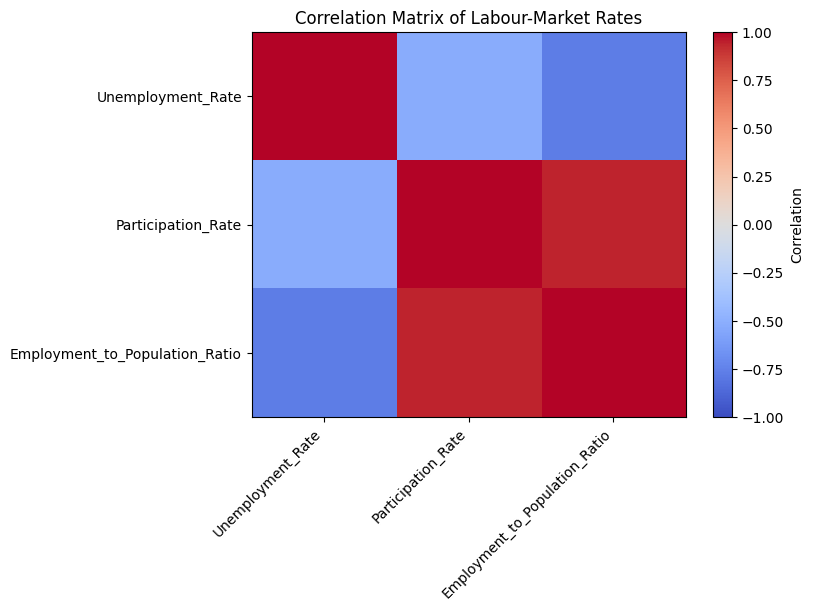

In [ ]:
plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(rate_cols)),
    rate_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(rate_cols)),
    rate_cols
)

plt.colorbar(label="Correlation")
plt.title("Correlation Matrix of Labour-Market Rates")
plt.show()


The pooled correlation analysis across the six states identifies clear relationships between the three labour-market rates. The unemployment rate has a **strong negative correlation with the employment-to-population ratio (r = −0.770)** and a **moderate negative correlation with the participation rate (r = −0.519)**. Participation and the employment-to-population ratio are **very strongly positively correlated (r = 0.945)**.

These results suggest that stronger employment conditions are generally associated with lower unemployment. However, the relationships are associative rather than causal, and the high correlation between participation and the employment-to-population ratio also indicates possible predictor redundancy that should be considered during model development.


### 4. Feature Engineering

The next stage transforms the cleaned state-month data into forecasting features. Because this is a multi-state time-series dataset, lagged values, rolling averages and change variables must be calculated **within each state** so that observations from one state are never used as the historical values of another state.

The intended forecasting task is to use information available at month *t* to predict each state's unemployment rate several months into the future.

In [ ]:
model_df = (
    df_010[df_010["State"].isin(MODEL_STATES)]
    .copy()
    .sort_values(["State", "Date"])
    .reset_index(drop=True)
)

In [ ]:
# Convert date
df_010["Date"] = pd.to_datetime(df_010["Date"], errors="coerce")

# Sort by date
df_006 = df_010.sort_values("Date").reset_index(drop=True)

# Check missing values
print(df_006.isna().sum())

# Check duplicates
print("Duplicate dates:", df_006.duplicated(subset=["Date"]).sum())

# Check data types
df_006.info()

# Preview
display(df_006.head())
display(df_006.tail())

Date                              0
State                             0
Employed_People_000               0
Employment_to_Population_Ratio    0
Unemployed_People_000             0
Unemployment_Rate                 0
Labour_Force_000                  0
Participation_Rate                0
dtype: int64
Duplicate dates: 3492
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4074 entries, 0 to 4073
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Date                            4074 non-null   datetime64[ns]
 1   State                           4074 non-null   object        
 2   Employed_People_000             4074 non-null   float64       
 3   Employment_to_Population_Ratio  4074 non-null   float64       
 4   Unemployed_People_000           4074 non-null   float64       
 5   Unemployment_Rate               4074 non-null   float64       
 6   Labour_Force_000      

,Date,State,Employed_People_000,Employment_to_Population_Ratio,Unemployed_People_000,Unemployment_Rate,Labour_Force_000,Participation_Rate
0,1978-02-01,Australia,5997.419207,57.176380,426.876934,6.644727,6424.296140,61.246011
1,1978-02-01,Victoria,1631.073237,57.602550,103.411543,5.962090,1734.484780,61.254604
2,1978-02-01,Western Australia,524.074710,59.272471,37.532863,6.683112,561.607572,63.517411
3,1978-02-01,New South Wales,2113.851057,56.582232,155.960744,6.871087,2269.811802,60.756891
4,1978-02-01,South Australia,553.523109,57.412916,42.243037,7.090540,595.766146,61.794478


,Date,State,Employed_People_000,Employment_to_Population_Ratio,Unemployed_People_000,Unemployment_Rate,Labour_Force_000,Participation_Rate
4069,2026-07-01,Queensland,3049.865949,64.204068,133.332581,4.188635,3183.198530,67.010911
4070,2026-07-01,Tasmania,283.840197,57.968805,15.123887,5.058764,298.964084,61.057563
4071,2026-07-01,New South Wales,4562.234495,63.402313,201.499816,4.229871,4763.734312,66.202597
4072,2026-07-01,South Australia,989.872559,61.465588,42.009508,4.071154,1031.882067,64.074145
4073,2026-07-01,Western Australia,1668.365889,64.998120,76.225977,4.369273,1744.591865,67.967819


In [ ]:
ab = df_010["Unemployment_Rate"].shift(1)

In [ ]:
# Lag features
df_010["Unemployment_Lag1"] = df_010["Unemployment_Rate"].shift(1)
df_010["Unemployment_Lag2"] = df_010["Unemployment_Rate"].shift(2)
df_010["Unemployment_Lag3"] = df_010["Unemployment_Rate"].shift(3)
df_010["Unemployment_Lag6"] = df_010["Unemployment_Rate"].shift(6)
df_010["Unemployment_Lag12"] = df_010["Unemployment_Rate"].shift(12)

# Rolling averages
df_010["Unemployment_Roll3"] = df_010["Unemployment_Rate"].rolling(3).mean()
df_010["Unemployment_Roll6"] = df_010["Unemployment_Rate"].rolling(6).mean()
df_010["Unemployment_Roll12"] = df_010["Unemployment_Rate"].rolling(12).mean()

# Predictor lags
df_010["Employment_Lag1"] = df_010["Employed_People_000"].shift(1)
df_010["EmploymentRatio_Lag1"] = df_010["Employment_to_Population_Ratio"].shift(1)
df_010["Unemployed_Lag1"] = df_010["Unemployed_People_000"].shift(1)
df_010["LabourForce_Lag1"] = df_010["Labour_Force_000"].shift(1)
df_010["Participation_Lag1"] = df_010["Participation_Rate"].shift(1)

In [ ]:
df_010["Unemployment_Change1"] = df_010["Unemployment_Rate"].diff(1)
df_010["Employment_Change1"] = df_010["Employed_People_000"].diff(1)
df_010["Participation_Change1"] = df_010["Participation_Rate"].diff(1)

In [ ]:
df_010["Month"] = df_010["Date"].dt.month
df_010["Quarter"] = df_010["Date"].dt.quarter
df_010["Year"] = df_010["Date"].dt.year

df_010["Month_Sin"] = np.sin(2 * np.pi * df_010["Month"] / 12)
df_010["Month_Cos"] = np.cos(2 * np.pi * df_010["Month"] / 12)


In [ ]:
df_010["Target_3M"] = df_010["Unemployment_Rate"].shift(-3)

In [ ]:
# Remove rows with missing values created by lag features and target shift
model_df = df_010.dropna().copy()

# Define features
features = [
    "Unemployment_Lag1",
    "Unemployment_Lag2",
    "Unemployment_Lag3",
    "Unemployment_Lag6",
    "Unemployment_Lag12",
    "Unemployment_Roll3",
    "Unemployment_Roll6",
    "Unemployment_Roll12",
    "Employment_Lag1",
    "EmploymentRatio_Lag1",
    "Unemployed_Lag1",
    "LabourForce_Lag1",
    "Participation_Lag1",
    "Unemployment_Change1",
    "Employment_Change1",
    "Participation_Change1",
    "Month_Sin",
    "Month_Cos"
]

target = "Target_3M"

In [ ]:
split_index = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

print("Training period:")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nTesting period:")
print(test_df["Date"].min(), "to", test_df["Date"].max())

Training period:
1978-02-01 00:00:00 to 2026-07-01 00:00:00

Testing period:
1978-02-01 00:00:00 to 2026-07-01 00:00:00


In [ ]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3247, 18)
X_test shape: (812, 18)


# 4. AI/statistical Model

A candidate machine-learning model is compared with a simple persistence baseline. The baseline assumes that the future unemployment rate will remain equal to the current rate. The AI model should demonstrate a meaningful improvement over this baseline on chronologically unseen observations.


In [ ]:
# !pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [ ]:
xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("XGBoost Model Performance")
print("-------------------------")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

XGBoost Model Performance
-------------------------
MAE:  0.3921
RMSE: 0.5175
R²:   0.9167


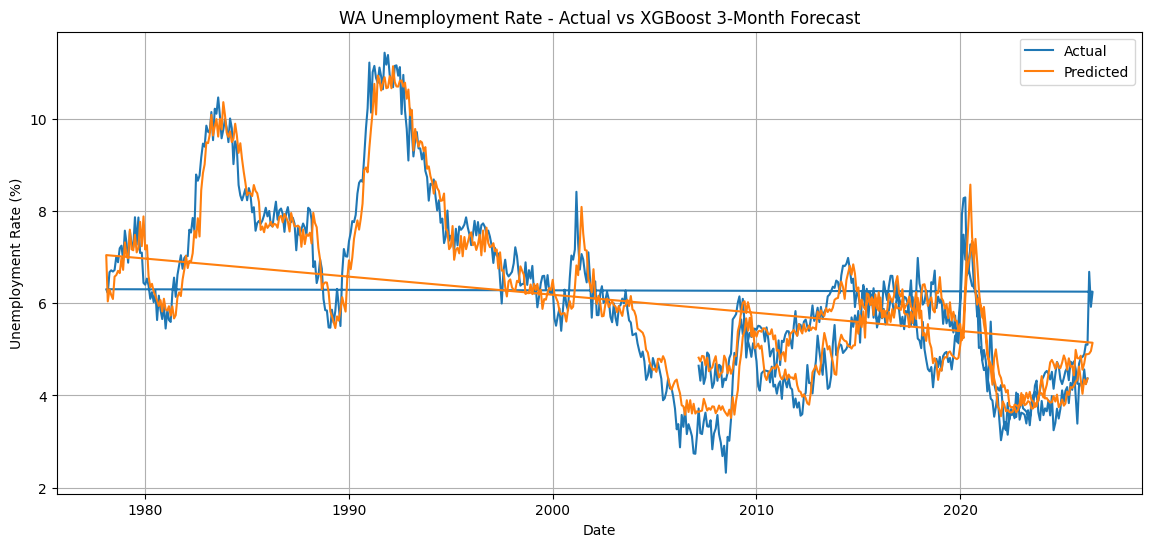

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test_df["Date"],
    y_test.values,
    label="Actual"
)

plt.plot(
    test_df["Date"],
    y_pred,
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title(
    "WA Unemployment Rate - Actual vs XGBoost 3-Month Forecast"
)

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
baseline_pred = test_df["Unemployment_Rate"].values

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("Persistence Baseline")
print("--------------------")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

Persistence Baseline
--------------------
MAE:  0.3879
RMSE: 0.5325
R²:   0.9118


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        mae
    ],
    "RMSE": [
        baseline_rmse,
        rmse
    ],
    "R2": [
        baseline_r2,
        r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Persistence Baseline,0.387931,0.532465,0.911844
1,XGBoost,0.392065,0.517529,0.916721


## Resources

In [ ]:
model_df = (
    model_df
    .sort_values(["State", "Date"])
    .reset_index(drop=True)
)

In [ ]:
for horizon in [1, 3, 6]:
    model_df[f"Target_{horizon}M"] = (
        model_df
        .groupby("State")["Unemployment_Rate"]
        .shift(-horizon)
    )

In [ ]:
model_df[
    [
        "Date",
        "State",
        "Unemployment_Rate",
        "Target_1M",
        "Target_3M",
        "Target_6M"
    ]
].tail(15)

,Date,State,Unemployment_Rate,Target_1M,Target_3M,Target_6M
4044,2025-02-01,Western Australia,3.498424,3.709423,3.860008,3.834001
4045,2025-03-01,Western Australia,3.709423,4.109668,4.099348,4.272578
4046,2025-04-01,Western Australia,4.109668,3.860008,4.181640,4.121701
4047,2025-05-01,Western Australia,3.860008,4.099348,3.834001,4.602321
4048,2025-06-01,Western Australia,4.099348,4.181640,4.272578,3.986297
4049,2025-07-01,Western Australia,4.181640,3.834001,4.121701,3.387990
4050,2025-08-01,Western Australia,3.834001,4.272578,4.602321,4.256231
4051,2025-09-01,Western Australia,4.272578,4.121701,3.986297,4.249081
4052,2025-10-01,Western Australia,4.121701,4.602321,3.387990,4.151514
4053,2025-11-01,Western Australia,4.602321,3.986297,4.256231,NaN


In [ ]:
for horizon in [1, 3, 6]:
    model_df[f"Target_Date_{horizon}M"] = (
        model_df["Date"]
        + pd.DateOffset(months=horizon)
    )

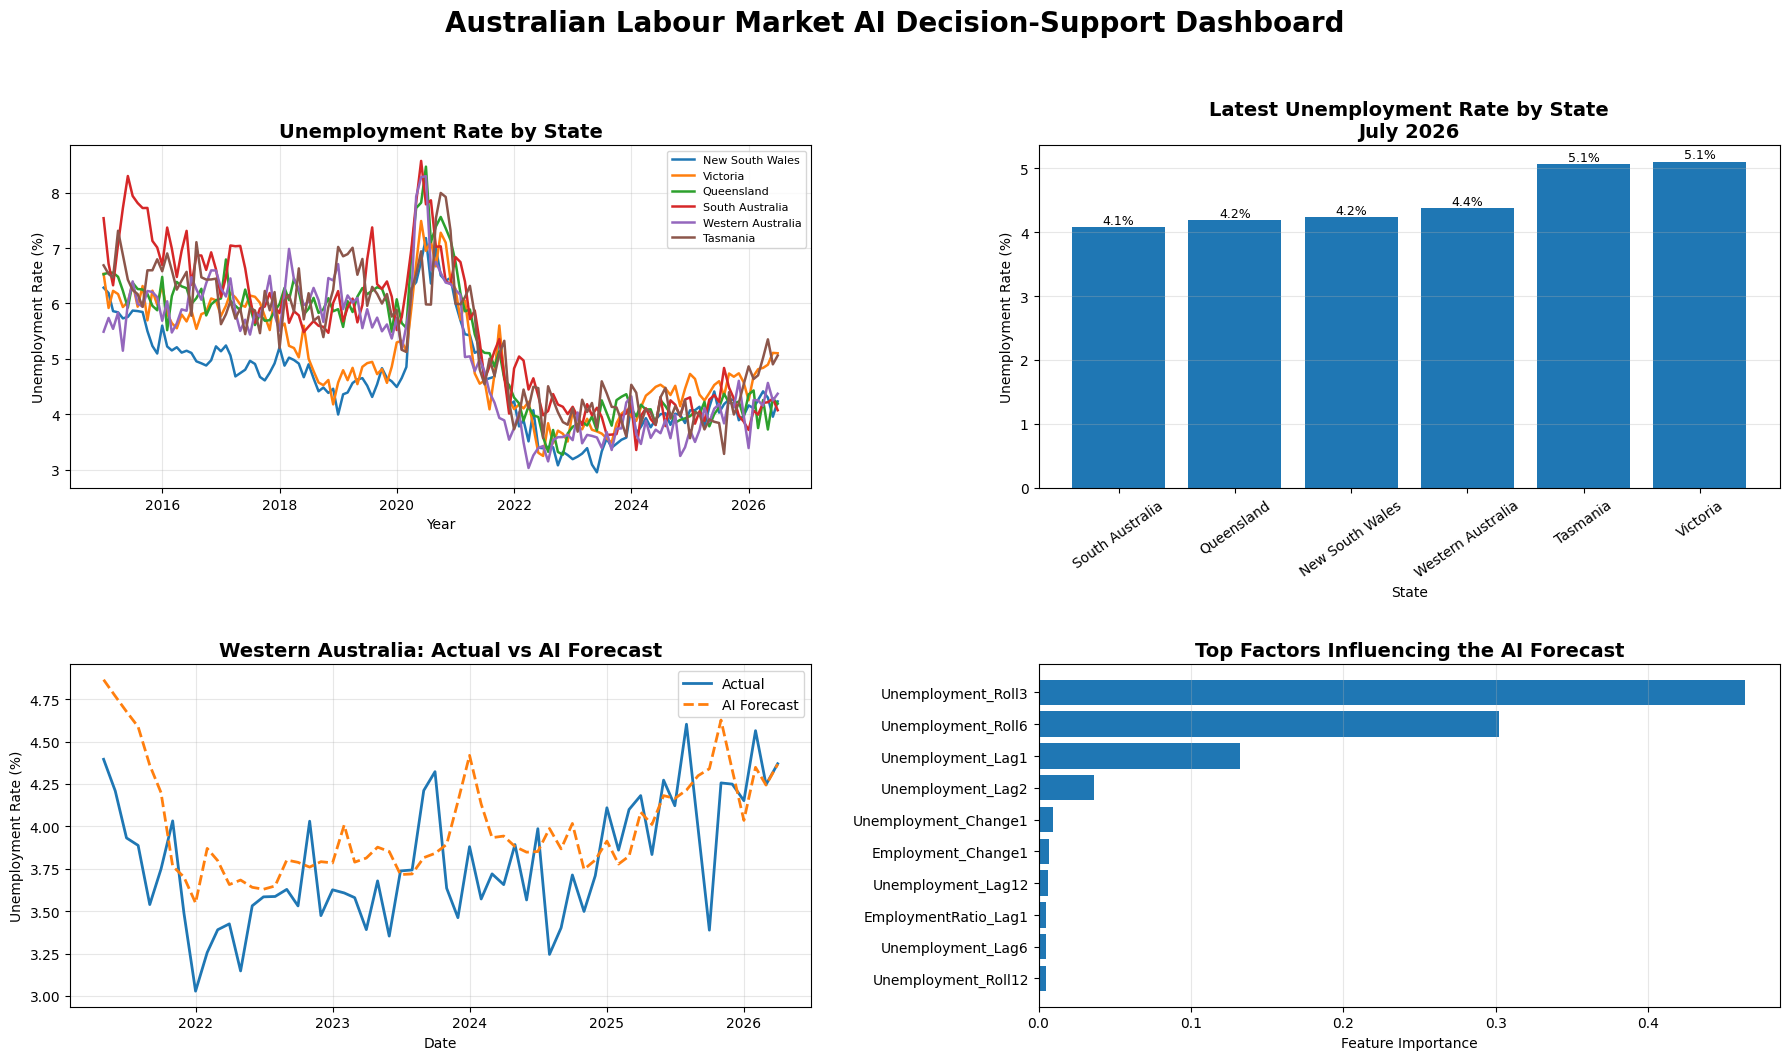

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# LABOURCAST AI DECISION-SUPPORT DASHBOARD

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

fig.suptitle(
    "Australian Labour Market AI Decision-Support Dashboard",
    fontsize=20,
    fontweight="bold"
)

# GRAPH 1: Unemployment Rate Trend by State

ax1 = axes[0, 0]

recent = df_010[
    (df_010["Date"] >= "2015-01-01") &
    (df_010["State"].isin(MODEL_STATES))
]

for state in MODEL_STATES:
    state_data = recent[recent["State"] == state]

    ax1.plot(
        state_data["Date"],
        state_data["Unemployment_Rate"],
        label=state,
        linewidth=1.8
    )

ax1.set_title(
    "Unemployment Rate by State",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Unemployment Rate (%)")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8)


# GRAPH 2: Latest Unemployment Rate by State

ax2 = axes[0, 1]

latest_date = df_010["Date"].max()

latest_states = (
    df_010[
        (df_010["Date"] == latest_date) &
        (df_010["State"].isin(MODEL_STATES))
    ]
    .sort_values("Unemployment_Rate")
)

bars = ax2.bar(
    latest_states["State"],
    latest_states["Unemployment_Rate"]
)

ax2.set_title(
    f"Latest Unemployment Rate by State\n{latest_date:%B %Y}",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("State")
ax2.set_ylabel("Unemployment Rate (%)")
ax2.tick_params(axis="x", rotation=35)

# Add values above bars
for bar, value in zip(
    bars,
    latest_states["Unemployment_Rate"]
):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

ax2.grid(axis="y", alpha=0.3)


# GRAPH 3: Actual vs AI Forecast

ax3 = axes[1, 0]

# Add predictions to test dataframe
forecast_df = test_df.copy()
forecast_df["Actual"] = np.array(y_test)
forecast_df["Predicted"] = y_pred

# Select WA for a clean dashboard example
wa_forecast = forecast_df[
    forecast_df["State"] == "Western Australia"
].sort_values("Date")

# Optional: only display recent observations
wa_forecast = wa_forecast.tail(60)

ax3.plot(
    wa_forecast["Date"],
    wa_forecast["Actual"],
    label="Actual",
    linewidth=2
)

ax3.plot(
    wa_forecast["Date"],
    wa_forecast["Predicted"],
    label="AI Forecast",
    linewidth=2,
    linestyle="--"
)

ax3.set_title(
    "Western Australia: Actual vs AI Forecast",
    fontsize=14,
    fontweight="bold"
)

ax3.set_xlabel("Date")
ax3.set_ylabel("Unemployment Rate (%)")
ax3.legend()
ax3.grid(alpha=0.3)


# GRAPH 4: XGBoost Feature Importance

ax4 = axes[1, 1]

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(10)
    .sort_values("Importance")
)

ax4.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

ax4.set_title(
    "Top Factors Influencing the AI Forecast",
    fontsize=14,
    fontweight="bold"
)

ax4.set_xlabel("Feature Importance")
ax4.set_ylabel("")
ax4.grid(axis="x", alpha=0.3)


# FINAL DASHBOARD LAYOUT

plt.tight_layout(
    rect=[0, 0.02, 1, 0.95],
    h_pad=3,
    w_pad=3
)

plt.show()